In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

# DATASET

In [5]:
# dataset reels
reels = pd.read_csv("/kaggle/input/datasets/filippotenani/cluster-data/reels_extracted.csv")

# dataset storie
stories = pd.read_csv("/kaggle/input/datasets/filippotenani/cluster-data/stories_extracted.csv")

# CLUSTERING FOLLOWER-PERFORMANCE

We want to understand if and how the size of a creator (measured by followers and reach) is associated with their performance (ENGAGE_RATE for Reels, CTR for Stories).

We aggregate data at the creator level by taking the median of their posts' performance, then apply KMeans on Reach, Followers and performance. The goal is to identify distinct creator profiles by size and compare their efficiency: we are not only interested in who reaches more people, but who does it with the greatest impact.

In [6]:
# AGGREGAZIONE PER CREATOR

# aggrega il dataset da un post per riga a un creator per riga
# prendendo la mediana di Reach, Followers e CTR/ENGAGE_RATE sui suoi post
# this because we want to do clustering on creators
def aggrega_creator(df, vars_raw):
    return df.groupby("Creator name")[vars_raw].median().reset_index().dropna()

stories_cr = aggrega_creator(stories, ["Reach", "Followers", "CTR"])
reels_cr   = aggrega_creator(reels,   ["Reach", "Followers", "ENGAGE_RATE"])

In [7]:
# LOG TRANSFORMATION

# log di Reach e Followers per ridurre impatto outliers
stories_cr["Reach_log"] = np.log1p(stories_cr["Reach"])
reels_cr["Reach_log"] = np.log1p(reels_cr["Reach"])
stories_cr["Followers_log"] = np.log1p(stories_cr["Followers"])
reels_cr["Followers_log"] = np.log1p(reels_cr["Followers"])

In [8]:
# VARIABILI

# variabili usate
STORIES_VARS = [
    "Reach_log", "Followers_log", "CTR",
]

REELS_VARS = [
    "Reach_log", "Followers_log", "ENGAGE_RATE",
]

# standardizziamo le variabili numeriche (media=0, std=1)
# necessario per KMeans che usa distanze euclidee
def prepara(df, vars):
    X = df[vars].dropna()
    idx = X.index
    X_scaled = StandardScaler().fit_transform(X)
    return X_scaled, idx

X_s, idx_s = prepara(stories_cr, STORIES_VARS)
X_r, idx_r = prepara(reels_cr,   REELS_VARS)

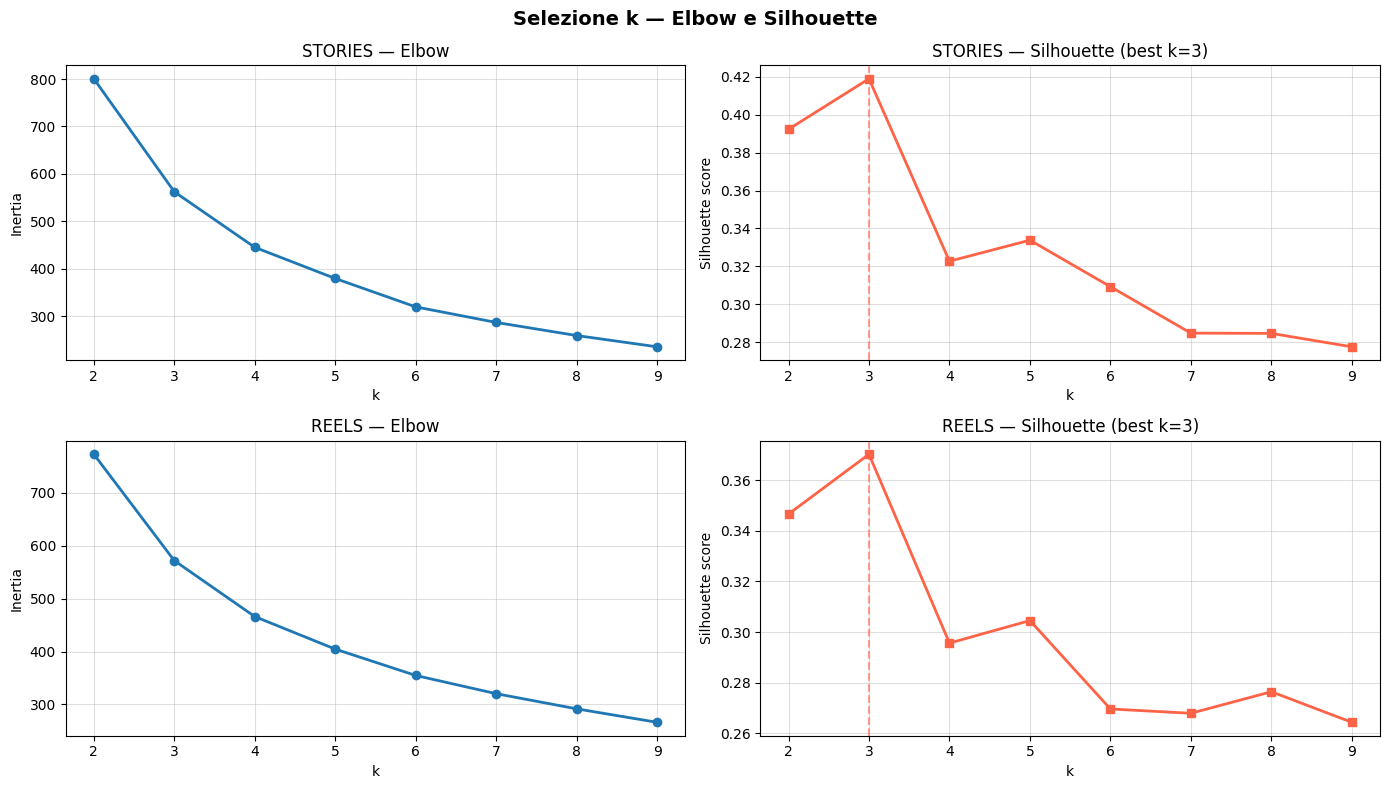

In [9]:
# RICERCA K OTTIMALE

# for each k we check elbow and silhouette score to choose the best k
def cerca_k(X, k_range=range(2, 10)):
    inertie, silhouette = [], []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=20)
        labels = km.fit_predict(X)
        inertie.append(km.inertia_)
        silhouette.append(silhouette_score(X, labels))
    return list(k_range), inertie, silhouette

ks_s, inert_s, sil_s = cerca_k(X_s)
ks_r, inert_r, sil_r = cerca_k(X_r)

# plot elbow e silhouette
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Selezione k — Elbow e Silhouette", fontsize=14, fontweight="bold")

for row, (ks, inert, sil, titolo) in enumerate([
    (ks_s, inert_s, sil_s, "STORIES"),
    (ks_r, inert_r, sil_r, "REELS"),
]):
    # elbow
    axes[row][0].plot(ks, inert, marker="o", lw=2)
    axes[row][0].set_title(f"{titolo} — Elbow")
    axes[row][0].set_xlabel("k")
    axes[row][0].set_ylabel("Inertia")
    axes[row][0].grid(alpha=0.4)

    # silhouette — evidenziamo il k migliore
    axes[row][1].plot(ks, sil, marker="s", lw=2, color="tomato")
    best_k = ks[np.argmax(sil)]
    axes[row][1].axvline(best_k, ls="--", alpha=0.6, color="tomato")
    axes[row][1].set_title(f"{titolo} — Silhouette (best k={best_k})")
    axes[row][1].set_xlabel("k")
    axes[row][1].set_ylabel("Silhouette score")
    axes[row][1].grid(alpha=0.4)

plt.tight_layout()
plt.show()

In [10]:
# CLUSTERING

# scegli tu k dopo aver visto i grafici
K_STORIES = 3
K_REELS = 3

# fittiamo KMeans con il k scelto e assegniamo le etichette al dataframe originale
labels_s = KMeans(n_clusters=K_STORIES, random_state=42, n_init=30).fit_predict(X_s)
labels_r = KMeans(n_clusters=K_REELS, random_state=42, n_init=30).fit_predict(X_r)

stories_cr.loc[idx_s, "cluster"] = labels_s
reels_cr.loc[idx_r,   "cluster"] = labels_r


# for each cluster we print variable means to draw a narrative for the clusters
def resoconto(df, num_vars, nome):
    print(f"  CLUSTER — {nome}")
    for k in sorted(df["cluster"].dropna().unique()):
        sub = df[df["cluster"] == k]
        print(f"\n  ── Cluster {int(k)+1}  (n={len(sub)},  {len(sub)/len(df)*100:.1f}%)")
        print("     Numeriche (media ± std):")
        
        for col in num_vars:
            # se la variabile è log-trasformata, stampiamo i valori originali
            if col.endswith("_log"):
                valori  = np.expm1(sub[col])
                label   = col.replace("_log", "")
                print(f"       {label:<28} {valori.mean():.0f}  ±  {valori.std():.0f}")
            else:
                print(f"       {col:<28} {sub[col].mean():.4f}  ±  {sub[col].std():.4f}")

resoconto(stories_cr, STORIES_VARS, "STORIES")
print("\n")
resoconto(reels_cr, REELS_VARS,   "REELS")

  CLUSTER — STORIES

  ── Cluster 1  (n=217,  48.4%)
     Numeriche (media ± std):
       Reach                        50706  ±  67559
       Followers                    821556  ±  703381
       CTR                          0.0040  ±  0.0043

  ── Cluster 2  (n=213,  47.5%)
     Numeriche (media ± std):
       Reach                        6481  ±  4600
       Followers                    126970  ±  87618
       CTR                          0.0063  ±  0.0046

  ── Cluster 3  (n=18,  4.0%)
     Numeriche (media ± std):
       Reach                        23995  ±  45512
       Followers                    276979  ±  236481
       CTR                          0.0390  ±  0.0165


  CLUSTER — REELS

  ── Cluster 1  (n=202,  49.3%)
     Numeriche (media ± std):
       Reach                        476185  ±  1123140
       Followers                    872495  ±  723765
       ENGAGE_RATE                  0.0342  ±  0.0213

  ── Cluster 2  (n=163,  39.8%)
     Numeriche (media ± std):
       

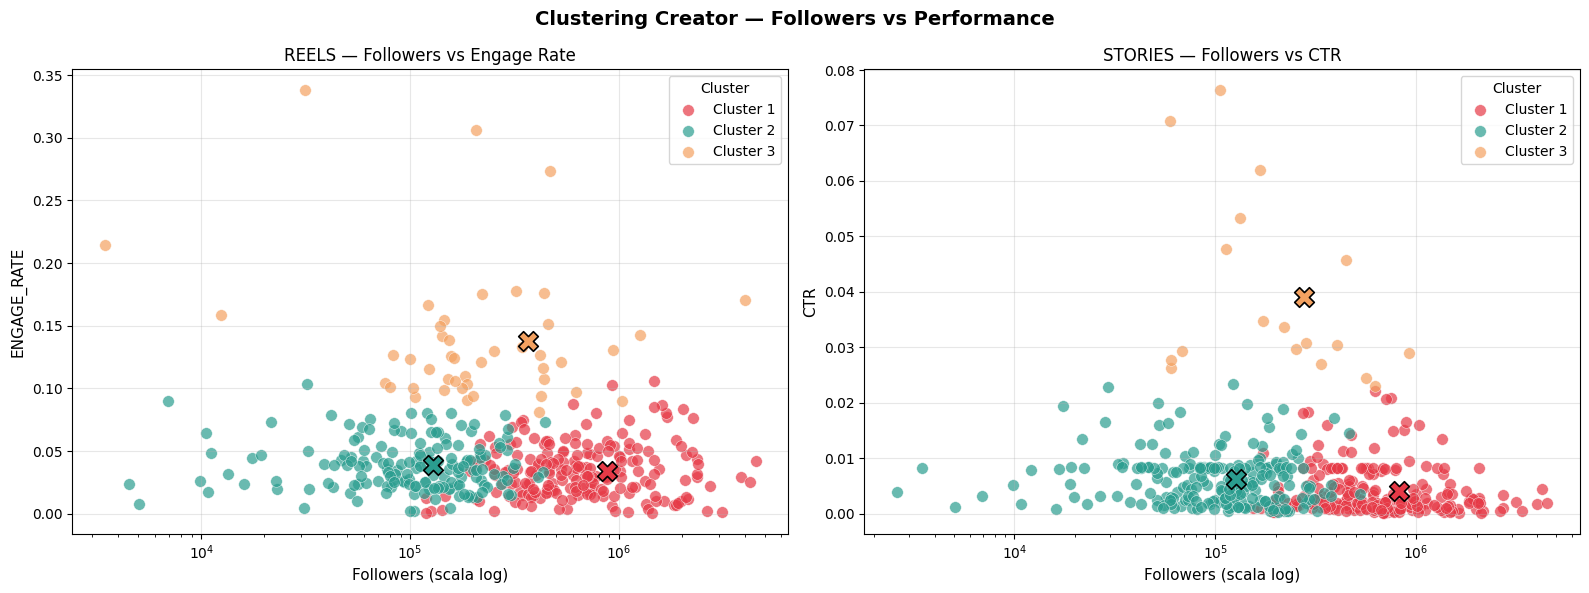

In [11]:
# PLOT CLUSTERS

CLUSTER_COLORS = {0: "#E63946", 1: "#2A9D8F", 2: "#F4A261"}
CLUSTER_NAMES  = {0: "Cluster 1", 1: "Cluster 2", 2: "Cluster 3"}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Clustering Creator — Followers vs Performance", fontsize=14, fontweight="bold")

for ax, df, x_col, y_col, title in [
    (axes[0], reels_cr,   "Followers", "ENGAGE_RATE", "REELS — Followers vs Engage Rate"),
    (axes[1], stories_cr, "Followers", "CTR",         "STORIES — Followers vs CTR"),
]:
    for k in sorted(df["cluster"].dropna().unique()):
        sub = df[df["cluster"] == k]
        ax.scatter(
            sub[x_col], sub[y_col],
            color=CLUSTER_COLORS[int(k)],
            label=CLUSTER_NAMES[int(k)],
            alpha=0.7, edgecolors="white", linewidths=0.4, s=70
        )
        # centroid
        ax.scatter(
            sub[x_col].mean(), sub[y_col].mean(),
            color=CLUSTER_COLORS[int(k)],
            marker="X", s=200, edgecolors="black", linewidths=1.2, zorder=5
        )
    ax.set_xscale("log")
    ax.set_xlabel("Followers (scala log)", fontsize=11)
    ax.set_ylabel(y_col, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(title="Cluster")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### INSIGHTS REELS CLUSTERING
CLUSTER 1: these are the Macro Influencers (~872K followers), the most numerous group, almost half of the creators, but they produce an average ENGAGE_RATE of 3.4%, the lowest.

CLUSTER 1: the Micro Influencers (~129K followers) do slightly better with 3.9%: the difference is minimal and probably not significant.

CLUSTER 1: the Mid-size Influencers (~368K followers) are only 11% of the sample but reach an average ENGAGE_RATE of 13.8%, about 4 times the Macro and 3.5 times the Micro.

So the Mid-size Influencers are clearly the most effective, with a strong and clear advantage over the other two groups. Macro and Micro are equivalent, so having more or fewer followers, without being in the mid-size range, makes no relevant difference on engagement.

### INSIGHTS STORIES CLUSTERING
For stories the picture is similar but even more pronounced.

CLUSTER 1: these are the Macro Influencers (~822K followers) and represent almost half of the creators, but they produce an average CTR of 0.40%, the lowest.

CLUSTER 2: these are the Micro Influencers (~127K followers) and represent about 40% of the creators, they do slightly better in terms of CTR with 0.63%, so the difference with Macro in terms of CTR is minimal and probably not significant.

CLUSTER 3: these are the Mid-size Influencers (~277K followers) and represent only 4% of the sample but reach an average CTR of 3.9%, almost 10 times the Macro and 6 times the Micro.

So the Mid-size Influencers are clearly the most effective, with an even more pronounced advantage than in Reels. Macro and Micro are equivalent, so also for Stories having more or fewer followers, without being in the mid-size range, makes no relevant difference on CTR.

# FRONTIERA DI PARETO

# PARETO FRONTIER

Clustering showed that mid-size creators are the most efficient. We now want to visualize it directly: for each creator we plot Followers vs Performance and trace the Pareto frontier, i.e. the set of "non-dominated" creators: those for whom no one else simultaneously has more followers and higher performance.

Creators on the frontier represent the best possible trade-off between audience size and content effectiveness and therefore constitute the optimal choice for each level of followers.

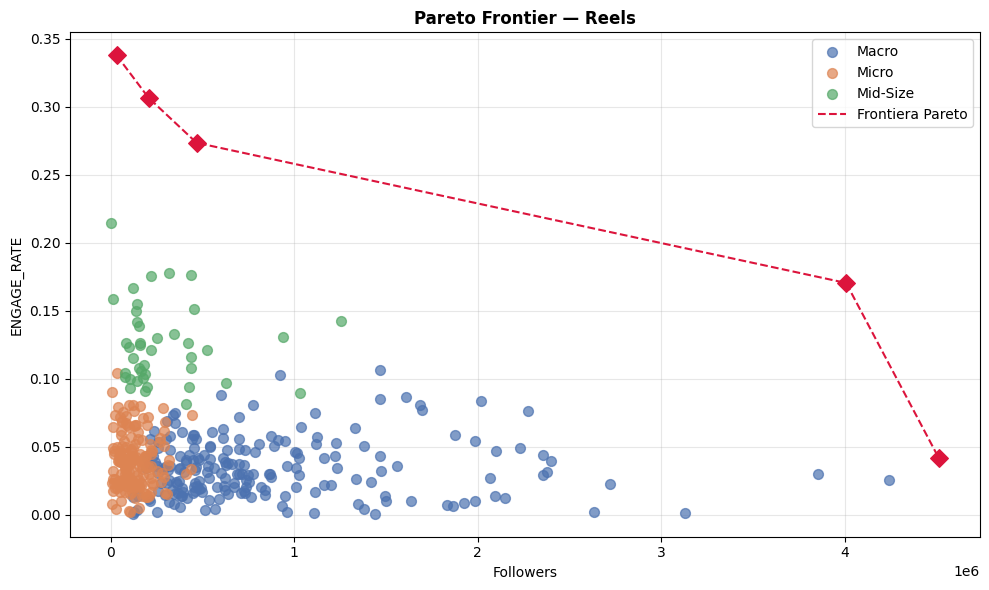


Creator sulla frontiera — Pareto Frontier — Reels
      Creator name  Followers  ENGAGE_RATE  cluster
       Aya Mohamed    31557.0     0.337694      2.0
     Davide Pisani   206015.0     0.306423      2.0
Pierpaolo Pretelli   467242.0     0.273355      2.0
   Ludovica Pagani  4006317.0     0.170265      2.0
    Trash Italiano  4510470.0     0.041749      0.0


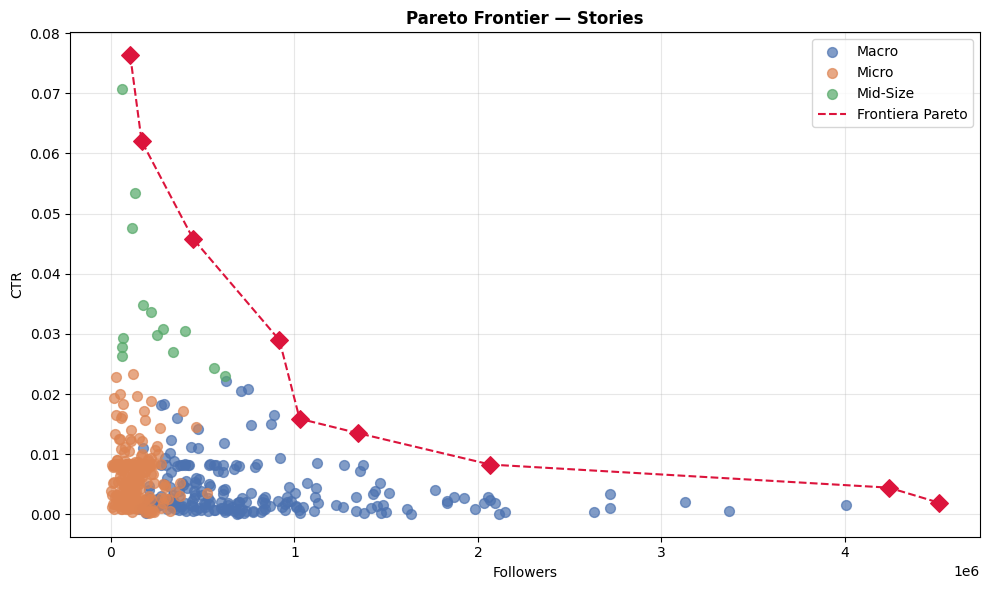


Creator sulla frontiera — Pareto Frontier — Stories
     Creator name  Followers      CTR  cluster
 Valentina Vigato   105066.0 0.076319      2.0
       Sabwayroll   167410.0 0.062032      2.0
    Laura Comolli   448061.0 0.045807      2.0
         Kid Yugi   917971.0 0.028986      2.0
Riccardo Marcuzzo  1028176.0 0.015902      0.0
  Claudia Dionigi  1346783.0 0.013509      0.0
Valentino Bisegna  2067790.0 0.008286      0.0
      Nonna Silvi  4239810.0 0.004450      0.0
   Trash Italiano  4510470.0 0.001964      0.0


In [12]:
import matplotlib.patches as mpatches

# FRONTIERA DI PARETO
# un creator è "non dominato" se nessun altro ha contemporaneamente
# followers maggiori E performance maggiore
def pareto_frontier(df, x_col, y_col):
    # ordina per x decrescente: scorriamo da più followers a meno followers
    df_sorted = df[[x_col, y_col, "cluster", "Creator name"]].dropna().sort_values(x_col, ascending=False).copy()
    
    # un punto è sulla frontiera se il suo y (performance) è >= al massimo y visto finora
    max_y = -np.inf
    on_frontier = []
    for _, row in df_sorted.iterrows():
        if row[y_col] >= max_y:
            on_frontier.append(True)
            max_y = row[y_col]
        else:
            on_frontier.append(False)
    
    df_sorted["on_frontier"] = on_frontier
    # ritorna tutto il df (per il plot) e solo i punti sulla frontiera separati
    return df_sorted, df_sorted[df_sorted["on_frontier"]].sort_values(x_col)


# colori e label dei cluster
COLORS = {0: "#4C72B0", 1: "#DD8452", 2: "#55A868"}
LABELS = {0: "Macro", 1: "Micro", 2: "Mid-Size"}


def plot_pareto(df, x_col, y_col, titolo):
    df_all, df_front = pareto_frontier(df, x_col, y_col)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # scatter di tutti i creator, colorati per cluster
    for cl, grp in df_all.groupby("cluster"):
        ax.scatter(
            grp[x_col], grp[y_col],
            c=COLORS[int(cl)], label=LABELS[int(cl)],
            alpha=0.7, s=50, zorder=2
        )
    
    # linea della frontiera di pareto
    ax.plot(
        df_front[x_col], df_front[y_col],
        color="crimson", lw=1.5, ls="--", zorder=3, label="Frontiera Pareto"
    )
    
    # evidenzia i punti sulla frontiera
    ax.scatter(
        df_front[x_col], df_front[y_col],
        color="crimson", s=80, zorder=4, marker="D"
    )
    
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(titolo, fontweight="bold")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # stampa i creator sulla frontiera con i loro valori
    print(f"\nCreator sulla frontiera — {titolo}")
    print(df_front[["Creator name", x_col, y_col, "cluster"]].to_string(index=False))


# ESECUZIONE
# reels: Followers vs ENGAGE_RATE
plot_pareto(reels_cr, "Followers", "ENGAGE_RATE", "Pareto Frontier — Reels")
# stories: Followers vs CTR
plot_pareto(stories_cr, "Followers", "CTR", "Pareto Frontier — Stories")

### PARETO FRONTIER
Each point is a creator. The frontier (red dashed line) connects the "non-dominated" creators: for each level of followers, they represent the maximum achievable engagement/CTR. Those below the frontier are dominated, meaning there is someone with fewer followers who does better, or someone with the same followers but higher performance.

### INSIGHTS REELS PARETO
For reels we have 5 creators on the frontier. 4 out of 5 are Mid-Size in terms of followers, only 1 Macro influencer. This confirms what clustering found in aggregate: Mid-Size are the most efficient creators.

The most interesting thing is the slope of the frontier: it drops sharply but not uniformly. From Aya Mohamed (31K followers, ER 33.8%) to Pierpaolo Pretelli (467K, ER 27.3%) the decline is slow, Mid-Size maintain very high performance even as followers grow. Then from Ludovica Pagani (4M, ER 17%) to Trash Italiano (4.5M, ER 4.2%) there is a vertical drop: just 500K more followers are enough to lose 13 percentage points of engagement. That (about 4M followers) is the breaking point.

Notable also that no Micro influencer is on the frontier, small creators have high engagement in absolute terms but Mid-Size beat them while having more followers.

### INSIGHTS STORIES PARETO
For stories the frontier is more populated (9 creators) and tells a more nuanced story. The first 4 are all Mid-Size creators, with CTR declining from 7.6% to 2.9% as followers grow from 100K to 1M. Then from 1M onwards the frontier becomes entirely Macro influencers and CTR drops below 1.6% never to rise again.

The frontier has a convex shape: the loss of efficiency per additional follower is maximum in the transition from Mid-Size to Macro (100K-1M followers), after which the curve flattens, so at that point adding millions more followers no longer changes anything.

The message is that for Stories the critical threshold is around 1M followers: above that threshold CTR practically zeroes out and even the best Macro do not exceed 1-2%.

### GENERAL INSIGHT
The Pareto frontier shows not just aggregate averages but real creators with names and surnames: creators offering the best follower/performance trade-off are named Davide Pisani, Pierpaolo Pretelli, Valentina Vigato, Laura Comolli, all Mid-Size.

# ESPORTARE DATASET CON CLUSTER

# EXPORT DATASET WITH CLUSTERS

Only for stories (because we have more data), when we do the regression, we will run a separate regression for each cluster, so now it is necessary to export the information about creators and which cluster each one belongs to.

Unfortunately we observe that for Mid-Size creators we have too few posts (68) to train a regression model only on them, so we will only consider macro and micro.

In [17]:
# associamo a ogni creator il suo cluster
CLUSTER_LABEL_STORIES = {0: "Macro", 1: "Micro", 2: "Mid-Size"}
stories_cr["cluster_name"] = stories_cr["cluster"].map(lambda x: CLUSTER_LABEL_STORIES[int(x)] if pd.notna(x) else np.nan)
stories_cr["cluster_name"].value_counts()

cluster_name
Macro       217
Micro       213
Mid-Size     18
Name: count, dtype: int64

In [18]:
# let's see how many posts we have for each cluster
for cluster in ["Macro", "Micro", "Mid-Size"]:
    creators = stories_cr[stories_cr["cluster_name"] == cluster]["Creator name"]
    n_post = stories[stories["Creator name"].isin(creators)].shape[0]
    print(f"{cluster}: {n_post} post")

Macro: 1200 post
Micro: 914 post
Mid-Size: 68 post


In [20]:
stories_cr[["Creator name", "cluster_name"]].sort_values("cluster_name").to_csv("stories_creator_cluster.csv", index=False)